In [1]:
import setup
from importlib import reload
reload(setup)
from setup import *

# LH 2

Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,0,0.42,15
,3000,0,0.35,7
,3000,0,0.38,7
,3000,0,0.40,7


Computed from 4000 posterior samples and 1476 observations log-likelihood matrix.

         Estimate       SE
elpd_loo  1729.88    59.55
p_loo        5.25        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)     1476  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



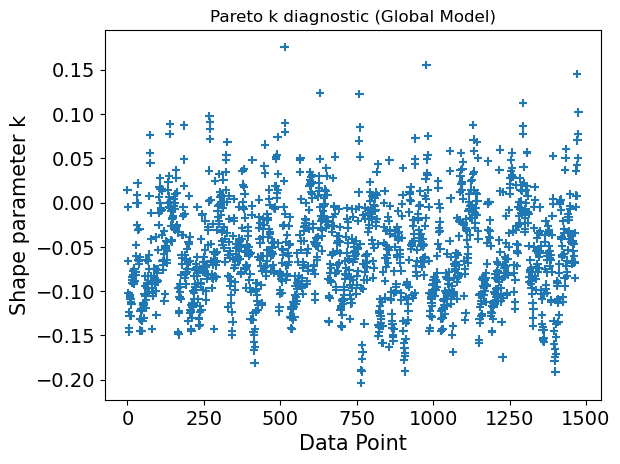

In [2]:
with pm.Model() as LH_2:
    '''
    1. CO + * <-> CO* (QEA)
    2. CO* + OH* -> COOH* + * (RDS)
    3. COOH* + OH- -> CO2 + H2O + * + (e-) (Fast)
    4. OH- + * <-> OH* + (e-) (QEA)
    '''
    # Priors
    deltaG1_0 = pm.Normal('deltaG1_0', mu=-0.4, sigma=0.2)
    deltaG4_0 = pm.Normal('deltaG4_0', mu=0.0, sigma=0.2) # at 0V_SHE
    Gact2_0 = pm.Normal('Gact2_0', mu=0.7, sigma=0.2)

    # Thermodynamics 
    deltaG1 = deltaG1_0
    deltaG4 = deltaG4_0 - E_in
    Gact2 = Gact2_0
    log_K1 = -deltaG1/(kb_eV*T)
    log_K4 = -deltaG4/(kb_eV*T)
    log_k2 = np.log(kb_J*T/h) - Gact2/(kb_eV*T)

    term_CO = log_K1 + np.log(P_CO_in)
    term_OH = log_K4 + np.log(C_KOH_in)
    zeros = pt.zeros_like(term_CO)
    log_theta = - pt.logsumexp(pt.stack([zeros, term_CO, term_OH]), axis=0)
    log_theta_CO = term_CO + log_theta
    log_theta_OH = term_OH + log_theta

    theta_CO = pm.Deterministic('theta_CO', pt.exp(log_theta_CO))
    theta_OH = pm.Deterministic('theta_OH', pt.exp(log_theta_OH))
    theta_empty = pm.Deterministic('theta_empty', pt.exp(log_theta))

    # Rate expression
    log_rate = log_k2 + log_theta_CO + log_theta_OH
    rate = observables(log_rate) 

trace_LH_2, loo_LH_2 = fit_and_evaluate(LH_2)

             mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
deltaG1_0  -0.035  0.003  -0.040   -0.030      0.000    0.000    2701.0    2613.0    1.0
deltaG4_0   0.112  0.005   0.102    0.121      0.000    0.000    1422.0    1348.0    1.0
Gact2_0     0.673  0.003   0.668    0.678      0.000    0.000    1545.0    1511.0    1.0
sigma_rel   0.583  0.032   0.527    0.644      0.001    0.001    1871.0    2408.0    1.0
sigma_base  0.000  0.000   0.000    0.001      0.000    0.000    2012.0    1233.0    1.0
exponent    0.605  0.011   0.584    0.625      0.000    0.000    1789.0    2302.0    1.0


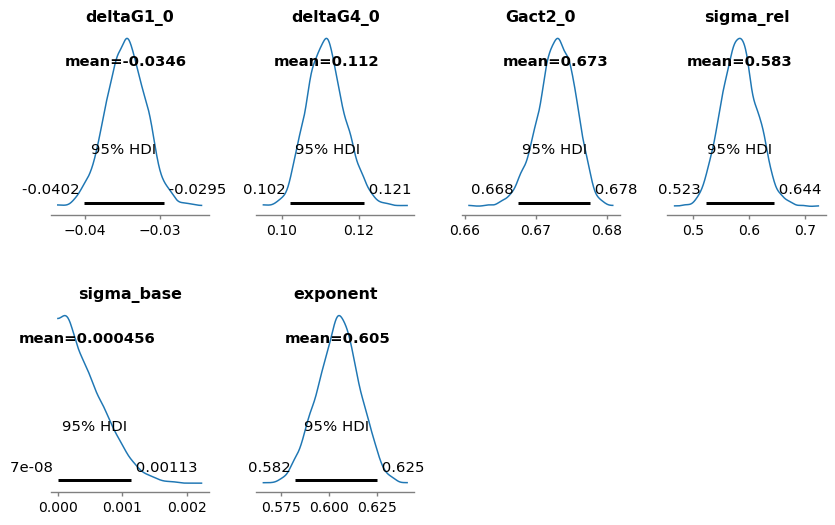

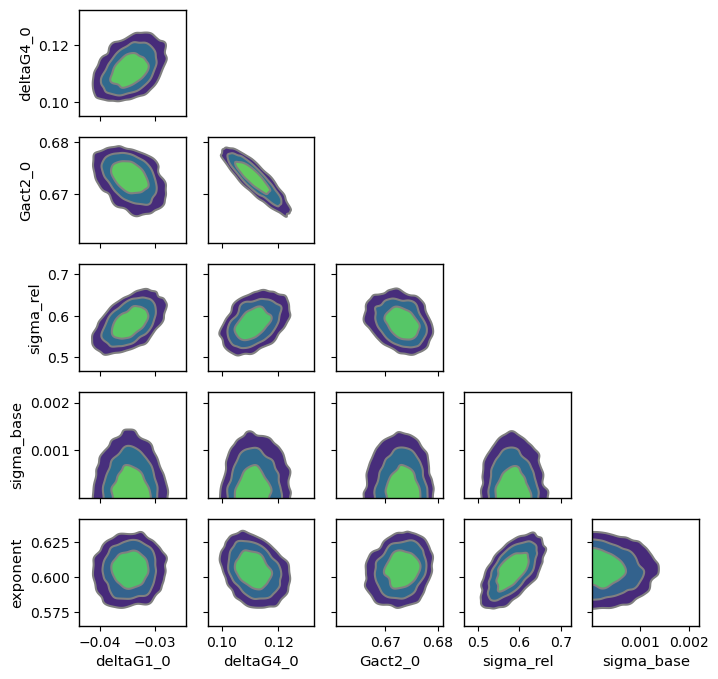

Sampling: [rate]


rate: 0.610


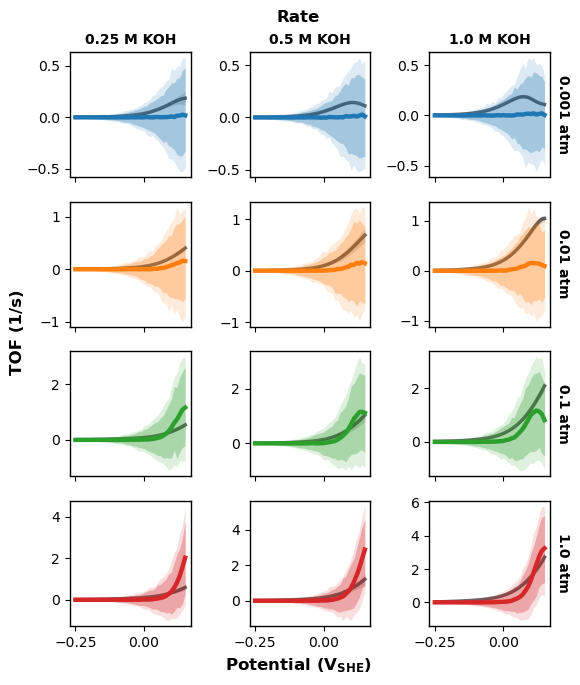

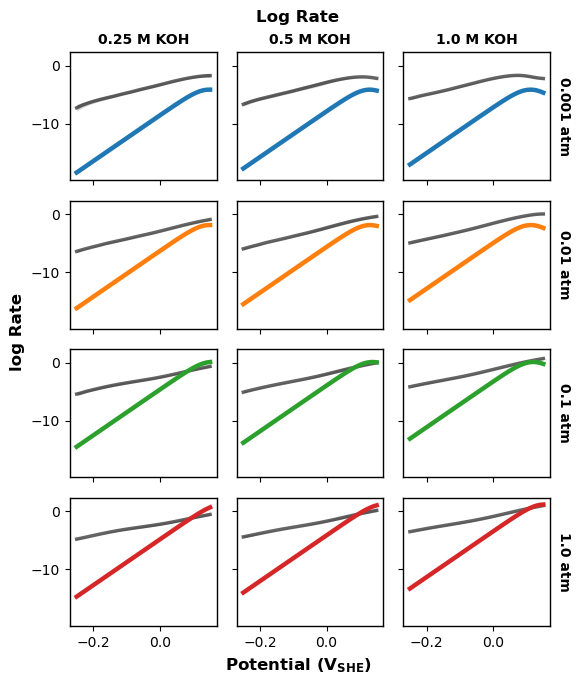

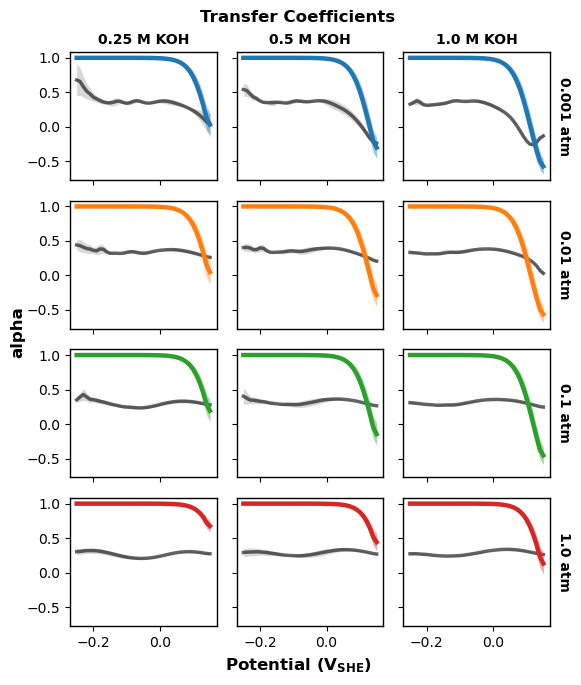

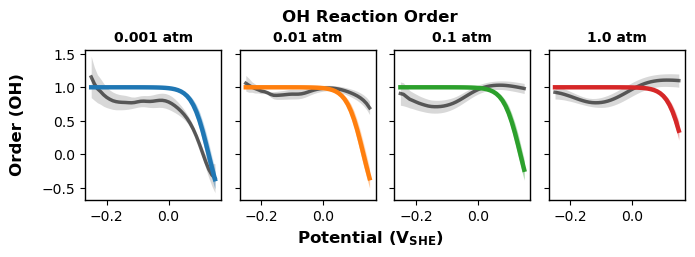

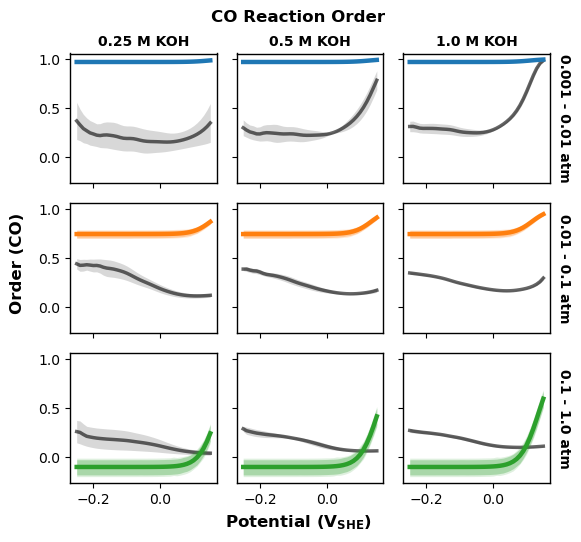

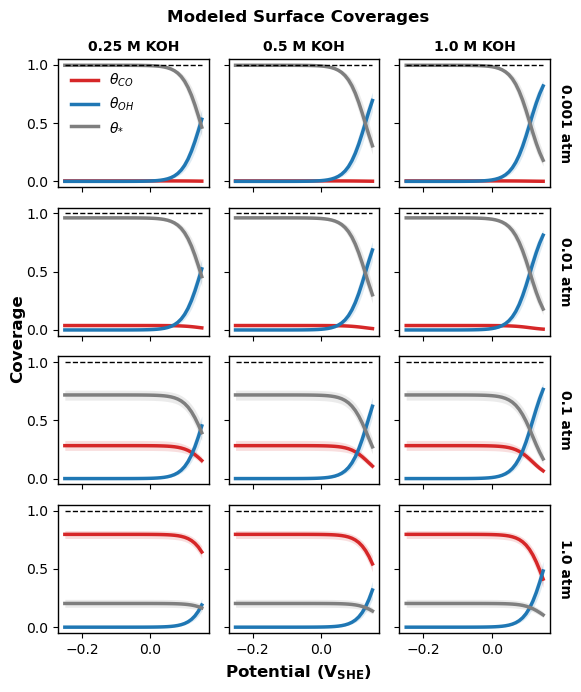

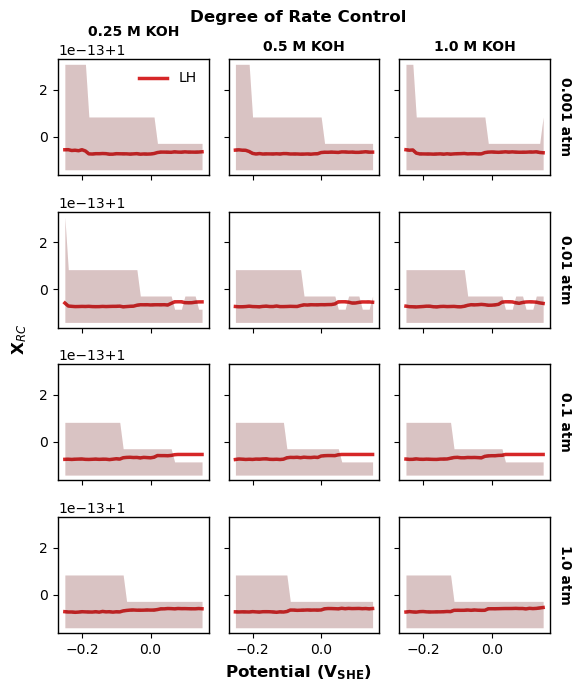

In [3]:
ppc_LH_2 = plot_posteriors(trace_LH_2, LH_2)
plot_model_fits(trace_LH_2, ppc_LH_2); plot_coverages(trace_LH_2)
plot_drc(LH_2, trace_LH_2, perturb_vars=['Gact2_0'], perturb_labels=['LH'])

# ER 2 

Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,0,0.42,15
,3000,0,0.45,7
,3000,0,0.44,31
,3000,0,0.43,7


Computed from 4000 posterior samples and 1476 observations log-likelihood matrix.

         Estimate       SE
elpd_loo  3558.15    56.57
p_loo        6.79        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)     1476  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



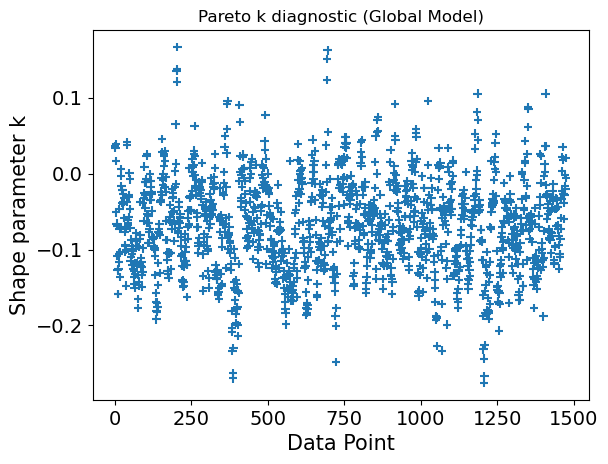

In [4]:
with pm.Model() as ER_2:
    '''
    1. CO + * <-> CO* (QEA)
    2. CO* + OH- -> COOH* + (e-) (RDS)
    3. COOH* + OH- -> CO2 + H2O + * + (e-) (Fast)
    4. OH- + * <-> OH* + (e-) (QEA)
    '''
    # Priors
    deltaG1_0 = pm.Normal('deltaG1_0', mu=-0.4, sigma=0.2)
    deltaG4_0 = pm.Normal('deltaG4_0', mu=0.0, sigma=0.2) # at 0V_SHE
    beta_2 = pm.Beta('beta_2', alpha=5, beta=5)   
    Gact2_0 = pm.Normal('Gact2_0', mu=0.7, sigma=0.2) # at 0V_SHE

    # Thermodynamics 
    deltaG1 = deltaG1_0
    deltaG4 = deltaG4_0 - E_in
    Gact2 = Gact2_0 - beta_2*E_in
    log_K1 = -deltaG1/(kb_eV*T)
    log_K4 = -deltaG4/(kb_eV*T)
    log_k2 = np.log(kb_J*T/h) - Gact2/(kb_eV*T)

    term_CO = log_K1 + np.log(P_CO_in)
    term_OH = log_K4 + np.log(C_KOH_in)
    zeros = pt.zeros_like(term_CO)
    log_theta = - pt.logsumexp(pt.stack([zeros, term_CO, term_OH]), axis=0)
    log_theta_CO = term_CO + log_theta
    log_theta_OH = term_OH + log_theta

    theta_CO = pm.Deterministic('theta_CO', pt.exp(log_theta_CO))
    theta_OH = pm.Deterministic('theta_OH', pt.exp(log_theta_OH))
    theta_empty = pm.Deterministic('theta_empty', pt.exp(log_theta))

    # Rate expression
    log_rate = log_k2 + log_theta_CO + np.log(C_KOH_in)
    rate = observables(log_rate) 

trace_ER_2, loo_ER_2 = fit_and_evaluate(ER_2)

             mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
deltaG1_0  -0.147  0.001  -0.149   -0.146      0.000    0.000    2446.0    2482.0    1.0
deltaG4_0   0.108  0.002   0.104    0.112      0.000    0.000    2338.0    2859.0    1.0
Gact2_0     0.769  0.000   0.769    0.770      0.000    0.000    3309.0    2917.0    1.0
beta_2      0.323  0.002   0.319    0.327      0.000    0.000    3287.0    2990.0    1.0
sigma_rel   0.132  0.007   0.119    0.145      0.000    0.000    2106.0    2302.0    1.0
sigma_base  0.000  0.000   0.000    0.000      0.000    0.000    2328.0    1645.0    1.0
exponent    1.498  0.033   1.441    1.568      0.001    0.001    2119.0    2253.0    1.0


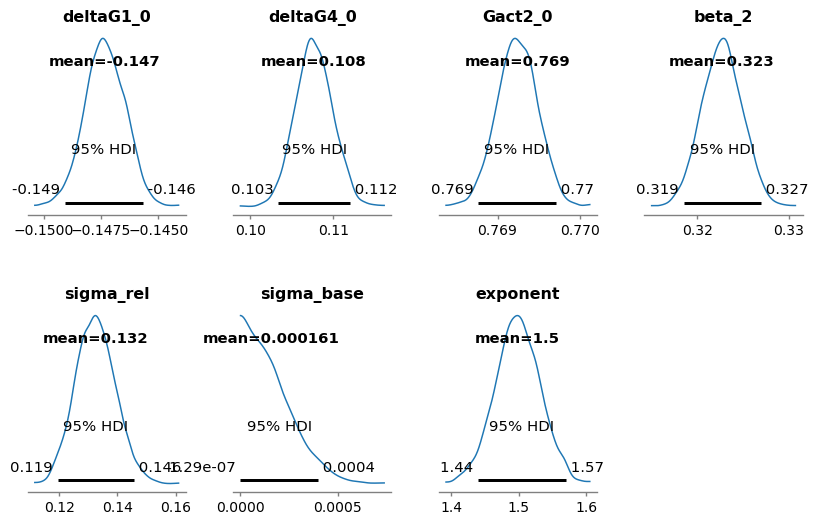

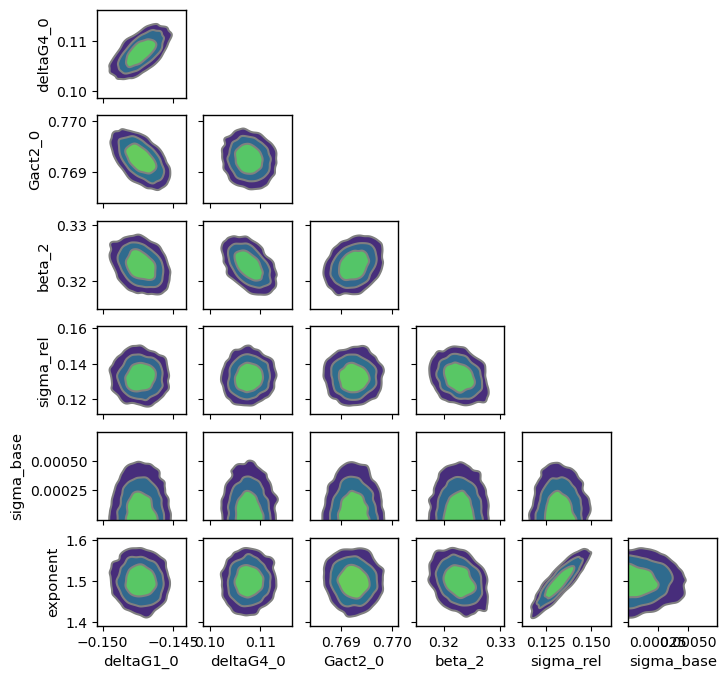

Sampling: [rate]


rate: 0.912


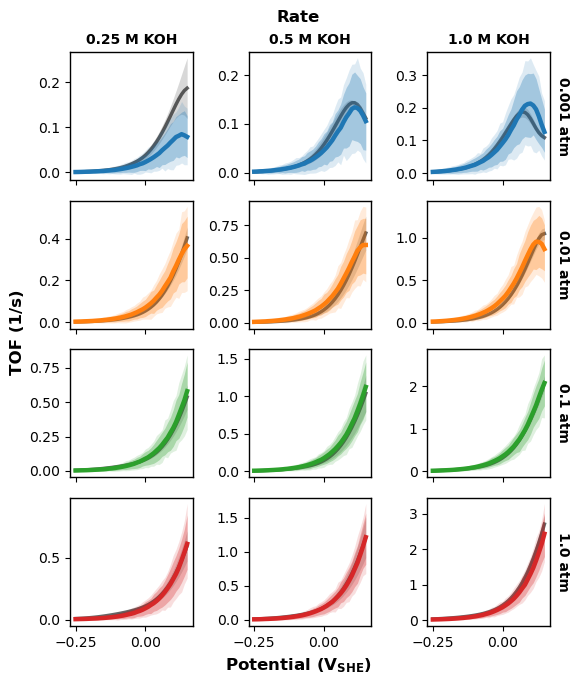

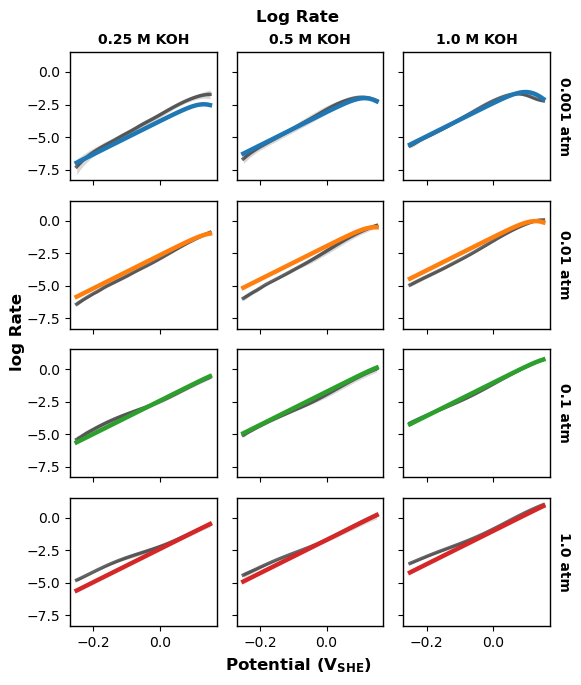

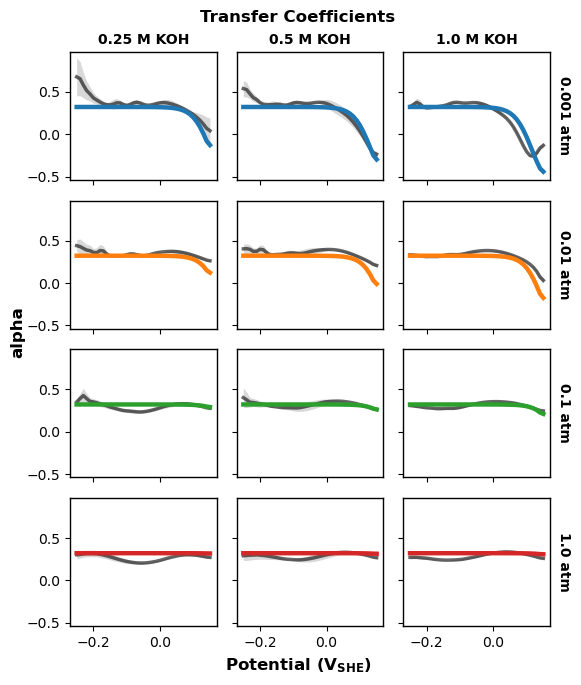

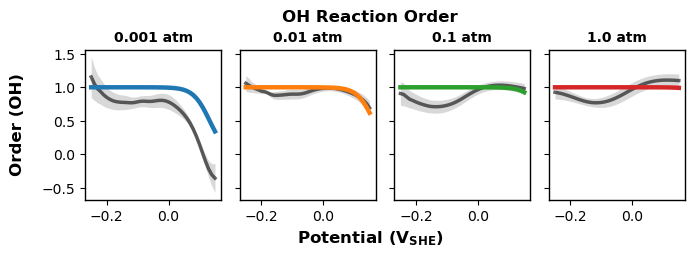

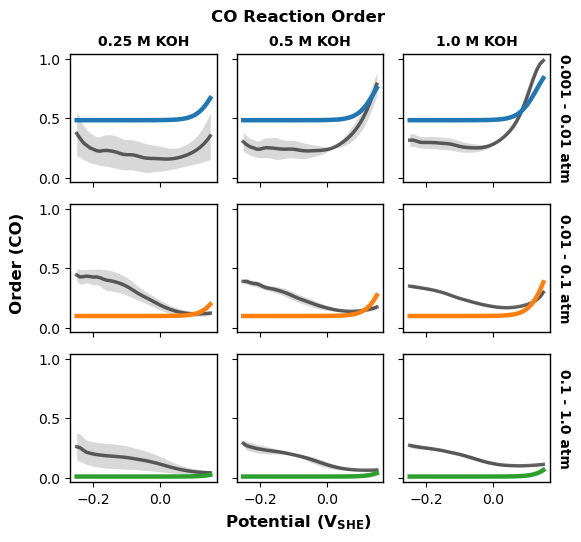

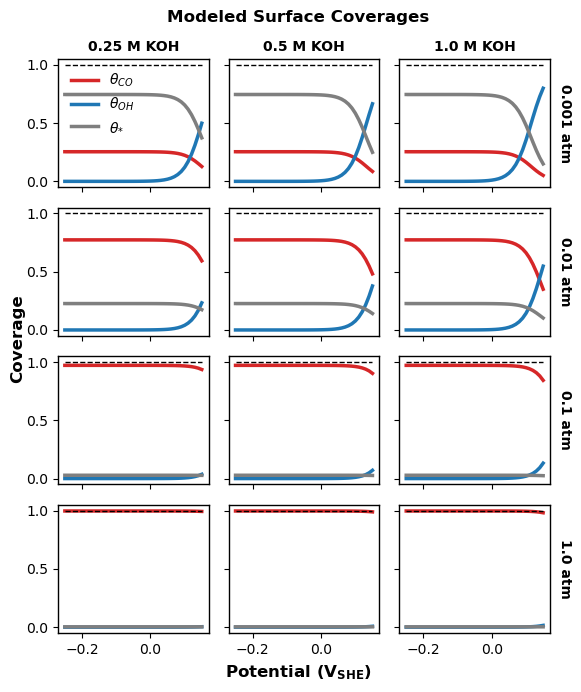

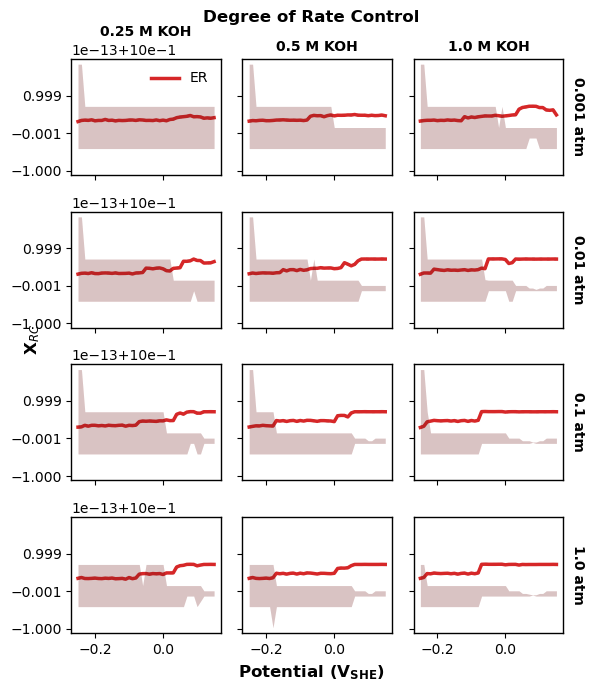

In [5]:
ppc_ER_2 = plot_posteriors(trace_ER_2, ER_2)
plot_model_fits(trace_ER_2, ppc_ER_2); plot_coverages(trace_ER_2)
plot_drc(ER_2, trace_ER_2, perturb_vars=['Gact2_0'], perturb_labels=['ER'])

# ER LH 2

Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,0,0.44,15
,3000,0,0.39,7
,3000,0,0.38,15
,3000,0,0.45,31


Computed from 4000 posterior samples and 1476 observations log-likelihood matrix.

         Estimate       SE
elpd_loo  3586.97    56.23
p_loo        8.28        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)     1476  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



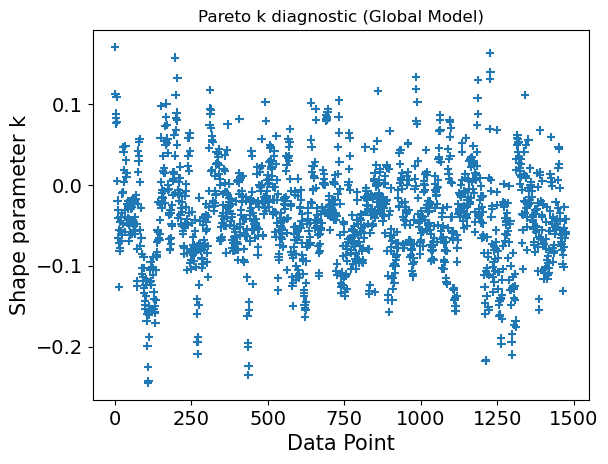

In [6]:
with pm.Model() as ER_LH_2:
    '''
    1. CO + * <-> CO* (QEA)
    2a. CO* + OH- -> COOH* + (e-) (RDS) (ER)
    2b. CO* + OH* -> COOH* + * (RDS) (LH)
    3. COOH* + OH- -> CO2 + H2O + * + (e-) (Fast)
    4. OH- + * <-> OH* + (e-) (QEA)
    '''
    # Priors
    deltaG1_0 = pm.Normal('deltaG1_0', mu=-0.4, sigma=0.2)
    deltaG4_0 = pm.Normal('deltaG4_0', mu=0.0, sigma=0.2) # at 0V_SHE
    beta_2 = pm.Beta('beta_2', alpha=5, beta=5)   
    Gact2_ER_0 = pm.Normal('Gact2_ER_0', mu=0.7, sigma=0.2) # at 0V_SHE
    Gact2_LH_0 = pm.Normal('Gact2_LH_0', mu=0.7, sigma=0.2)

    # Thermodynamics 
    deltaG1 = deltaG1_0
    deltaG4 = deltaG4_0 - E_in
    Gact2_ER = Gact2_ER_0 - beta_2*E_in
    Gact2_LH = Gact2_LH_0
    log_K1 = -deltaG1/(kb_eV*T)
    log_K4 = -deltaG4/(kb_eV*T)
    log_k2_ER = np.log(kb_J*T/h) - Gact2_ER/(kb_eV*T)
    log_k2_LH = np.log(kb_J*T/h) - Gact2_LH/(kb_eV*T)

    term_CO = log_K1 + np.log(P_CO_in)
    term_OH = log_K4 + np.log(C_KOH_in)
    zeros = pt.zeros_like(term_CO)
    log_theta = - pt.logsumexp(pt.stack([zeros, term_CO, term_OH]), axis=0)
    log_theta_CO = term_CO + log_theta
    log_theta_OH = term_OH + log_theta

    theta_CO = pm.Deterministic('theta_CO', pt.exp(log_theta_CO))
    theta_OH = pm.Deterministic('theta_OH', pt.exp(log_theta_OH))
    theta_empty = pm.Deterministic('theta_empty', pt.exp(log_theta))

    # Rate expression
    log_rate_LH = log_k2_LH + log_theta_CO + log_theta_OH
    log_rate_ER = log_k2_ER + log_theta_CO + np.log(C_KOH_in)
    log_rate = pt.logaddexp(log_rate_LH, log_rate_ER)
    rate = observables(log_rate) 

trace_ER_LH_2, loo_ER_LH_2 = fit_and_evaluate(ER_LH_2)

             mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
deltaG1_0  -0.145  0.001  -0.147   -0.144      0.000    0.000    2570.0    2342.0    1.0
deltaG4_0   0.095  0.002   0.091    0.099      0.000    0.000    3415.0    2730.0    1.0
Gact2_ER_0  0.769  0.000   0.769    0.770      0.000    0.000    3461.0    2893.0    1.0
Gact2_LH_0  0.747  0.003   0.741    0.752      0.000    0.000    2569.0    2770.0    1.0
beta_2      0.317  0.002   0.313    0.321      0.000    0.000    3361.0    3271.0    1.0
sigma_rel   0.138  0.007   0.126    0.152      0.000    0.000    1996.0    2353.0    1.0
sigma_base  0.000  0.000   0.000    0.000      0.000    0.000    2473.0    1264.0    1.0
exponent    1.537  0.032   1.478    1.601      0.001    0.001    2032.0    2283.0    1.0


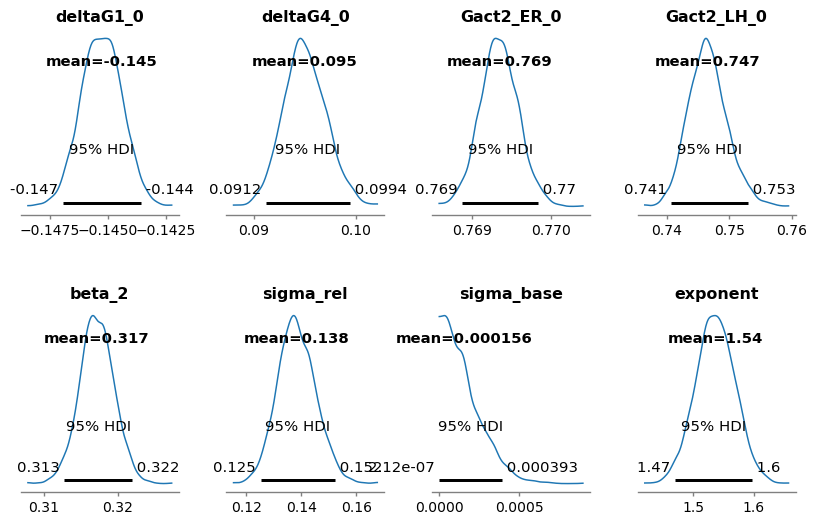

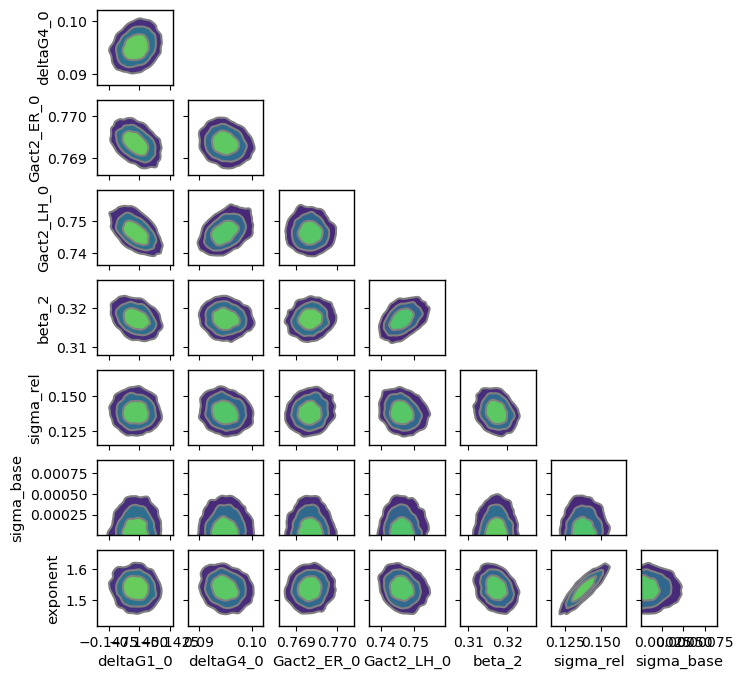

Sampling: [rate]


rate: 0.899


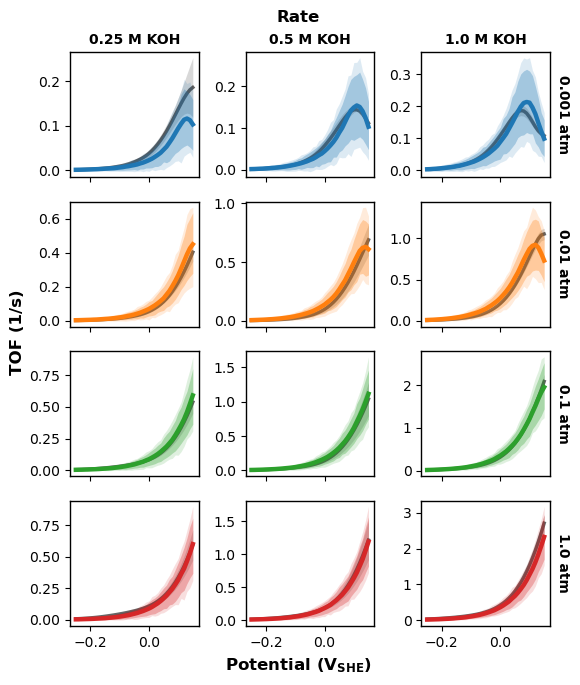

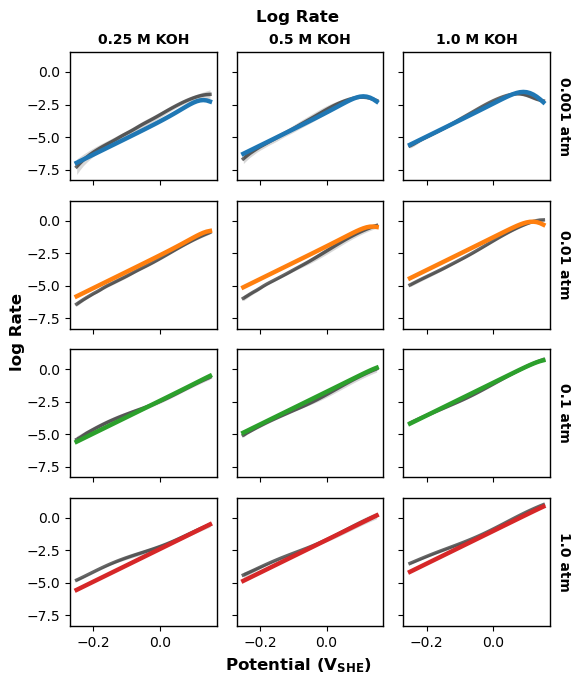

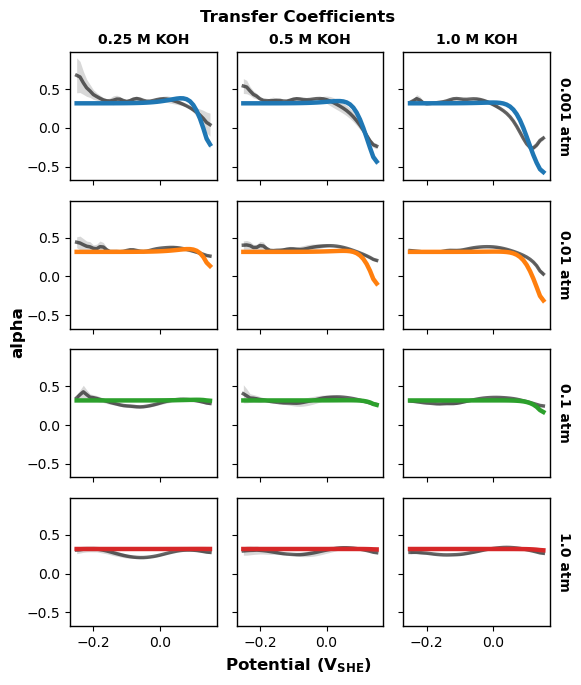

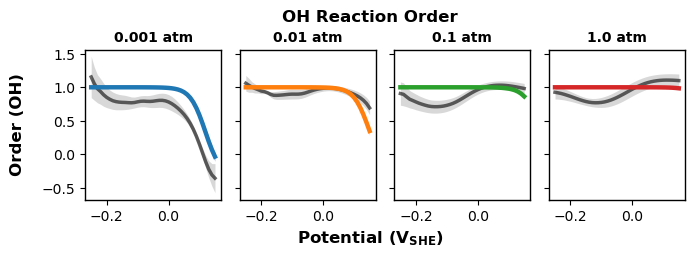

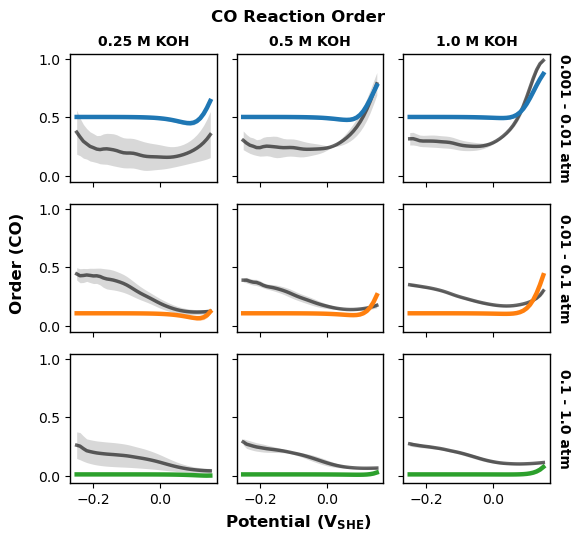

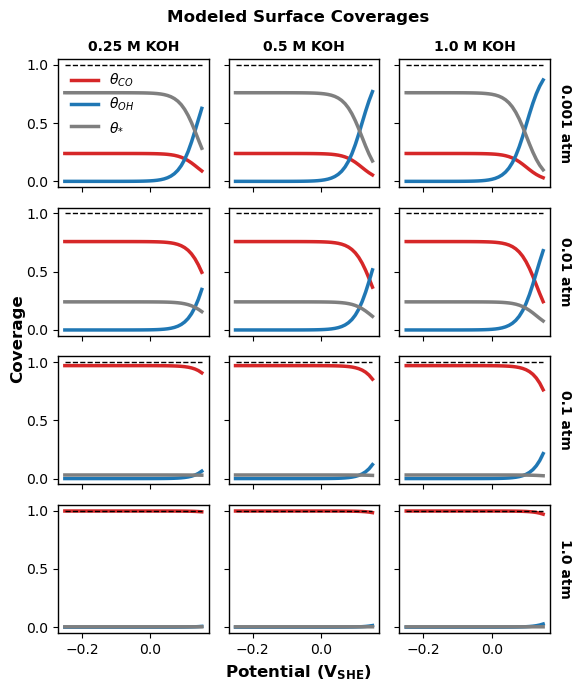

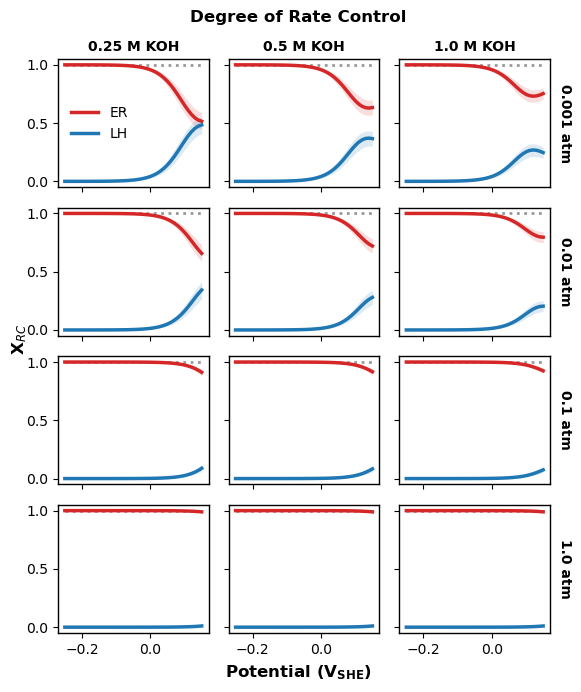

In [7]:
ppc_ER_LH_2 = plot_posteriors(trace_ER_LH_2, ER_LH_2)
plot_model_fits(trace_ER_LH_2, ppc_ER_LH_2); plot_coverages(trace_ER_LH_2)
plot_drc(ER_LH_2, trace_ER_LH_2, perturb_vars=['Gact2_ER_0', 'Gact2_LH_0'], perturb_labels=['ER', 'LH'])

# Comparison

         rank     elpd_loo     p_loo    elpd_diff        weight         se        dse  warning scale
ER_LH_2     0  3586.967397  8.278359     0.000000  8.735242e-01  56.233809   0.000000    False   log
ER_2        1  3558.145570  6.791897    28.821827  1.264758e-01  56.565479   9.364907    False   log
LH_2        2  1729.875246  5.246002  1857.092151  3.479883e-12  59.553796  27.945390    False   log


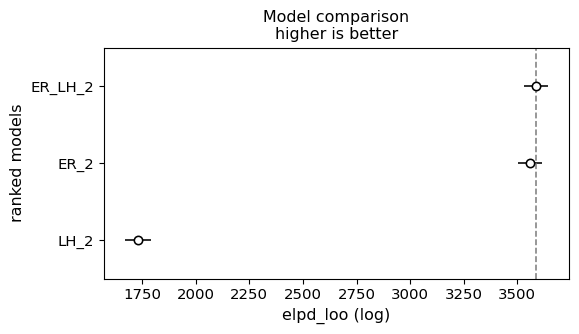

In [8]:
comparison_dict = {
    "LH_2": loo_LH_2,
    "ER_2": loo_ER_2,
    "ER_LH_2": loo_ER_LH_2
}

comp_df = az.compare(comparison_dict, ic="loo", method="stacking")
print(comp_df)
az.plot_compare(comp_df, insample_dev=False)
plt.show()